In [10]:
%pip install pandas pyarrow openpyxl
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.3 MB 13.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.2/9.3 MB 13.8 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 12.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------- ------------------------- 2.6/7.2 MB 12.6 MB/s eta 0:00:01
   ---------------------------- ----------- 5.2/7.2 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 12.8 MB/s  0:00:00

   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   --

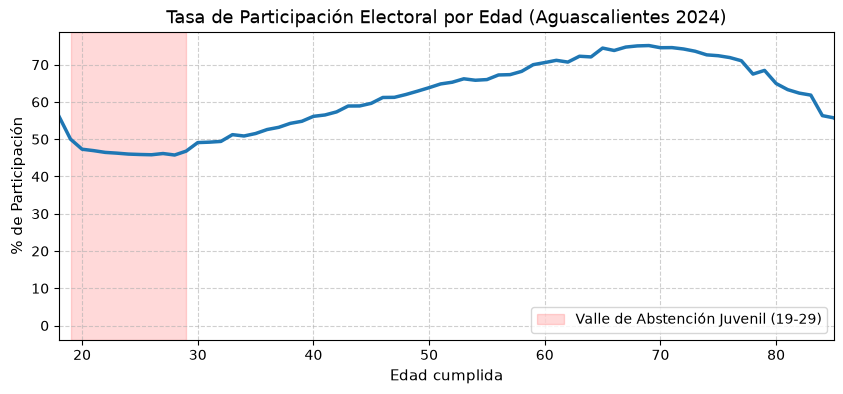


De 91,826 filas originales se redujo a: 663 secciones electorales.


,EDOCVE,EDONOM,MPIOCVE,MPIONOM,SECCION,TIPOSEC,DEF,ln_total,sv_total,nv_total,participacion,pct_jovenes,part_jovenes,pct_18,pct_mayores_65,ratio_mujeres
0,1,AGUASCALIENTES,1,Aguascalientes,1,U,3,2336.0,1859.0,477.0,0.795805,0.219606,0.695906,0.014555,0.205479,0.536815
1,1,AGUASCALIENTES,1,Aguascalientes,2,U,3,926.0,541.0,385.0,0.584233,0.249460,0.424242,0.011879,0.198704,0.517279
2,1,AGUASCALIENTES,1,Aguascalientes,3,U,3,1750.0,1258.0,492.0,0.718857,0.216000,0.653439,0.013714,0.181143,0.537143
3,1,AGUASCALIENTES,1,Aguascalientes,4,U,3,1399.0,995.0,404.0,0.711222,0.215154,0.601329,0.009292,0.148678,0.541101
4,1,AGUASCALIENTES,1,Aguascalientes,5,U,3,748.0,493.0,255.0,0.659091,0.191176,0.545455,0.002674,0.252674,0.548128


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Comprobar la famosa "Curva por Edad" (Nivel Estatal)
# Agrupamos por edad cumplida para ver cómo vota cada grupo etario
df_edad = df_muestra.groupby("EDAD")[["LN", "SV", "NV"]].sum()
df_edad["tasa_participacion"] = (df_edad["SV"] / df_edad["LN"]) * 100

# Graficar la curva de participación por edad
plt.figure(figsize=(10, 4))
plt.plot(df_edad.index, df_edad["tasa_participacion"], color="#1f77b4", lw=2.5)
plt.title("Tasa de Participación Electoral por Edad (Aguascalientes 2024)", fontsize=13)
plt.xlabel("Edad cumplida", fontsize=11)
plt.ylabel("% de Participación", fontsize=11)
plt.axvspan(19, 29, color="red", alpha=0.15, label="Valle de Abstención Juvenil (19-29)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xlim(18, 85)
plt.show()

# 2. Función para compactar un estado a nivel SECCIÓN ELECTORAL
def procesar_secciones(df):
    # Filtros por grupos etarios clave
    df["es_joven_19_29"] = df["EDAD"].between(19, 29)
    df["es_18"] = df["EDAD"] == 18
    df["es_mayor_65"] = df["EDAD"] >= 65
    df["es_mujer"] = df["SEXO"] == 1

    # Agrupación por sección
    secciones = df.groupby(["EDOCVE", "EDONOM", "MPIOCVE", "MPIONOM", "SECCION", "TIPOSEC", "DEF"]).apply(
        lambda g: pd.Series({
            "ln_total": g["LN"].sum(),
            "sv_total": g["SV"].sum(),
            "nv_total": g["NV"].sum(),
            "participacion": (g["SV"].sum() / g["LN"].sum()) if g["LN"].sum() > 0 else 0,
            
            # Variables demográficas de lista nominal
            "pct_jovenes": g.loc[g["es_joven_19_29"], "LN"].sum() / g["LN"].sum(),
            "part_jovenes": (g.loc[g["es_joven_19_29"], "SV"].sum() / g.loc[g["es_joven_19_29"], "LN"].sum()) if g.loc[g["es_joven_19_29"], "LN"].sum() > 0 else 0,
            "pct_18": g.loc[g["es_18"], "LN"].sum() / g["LN"].sum(),
            "pct_mayores_65": g.loc[g["es_mayor_65"], "LN"].sum() / g["LN"].sum(),
            "ratio_mujeres": g.loc[g["es_mujer"], "LN"].sum() / g["LN"].sum()
        })
    ).reset_index()
    
    return secciones

df_secciones_ags = procesar_secciones(df_muestra)
print(f"\nDe 91,826 filas originales se redujo a: {len(df_secciones_ags):,} secciones electorales.")
display(df_secciones_ags.head())

In [12]:
import os
import glob
import pandas as pd

archivos = sorted(glob.glob("../data/processed/secciones_*.parquet"))
resumen = []

print("Auditando los 6 archivos Parquet...\n")

ids_por_ano = {}

for ruta in archivos:
    df = pd.read_parquet(ruta)
    anio = df["AELEC"].iloc[0] if "AELEC" in df.columns else os.path.basename(ruta)
    
    # 1. Métricas macro
    total_secciones = len(df)
    ln_nacional = df["ln_total"].sum()
    sv_nacional = df["sv_total"].sum()
    participacion_ponderada = (sv_nacional / ln_nacional) * 100 if ln_nacional > 0 else 0
    
    # 2. Métricas demográficas promedio
    pct_jovenes_medio = df["pct_jovenes_19_29"].mean() * 100
    pct_mujeres_medio = df["ratio_mujeres"].mean() * 100
    
    # 3. Control de calidad
    nulos = df[["participacion", "ln_total", "id_seccion"]].isnull().sum().sum()
    anomalias_part = (df["participacion"] > 1.0).sum() # Casillas con > 100%
    
    ids_por_ano[anio] = set(df["id_seccion"])

    resumen.append({
        "Año": anio,
        "Secciones": f"{total_secciones:,}",
        "Lista Nominal": f"{ln_nacional / 1e6:.1f} M",
        "Votos (SV)": f"{sv_nacional / 1e6:.1f} M",
        "Participación Nac.": f"{participacion_ponderada:.2f}%",
        "Prom. Jóvenes": f"{pct_jovenes_medio:.1f}%",
        "Prom. Mujeres": f"{pct_mujeres_medio:.1f}%",
        "Nulos": nulos,
        "Participación > 100%": anomalias_part
    })

df_auditoria = pd.DataFrame(resumen)
display(df_auditoria)

# 4. Probar continuidad histórica
secciones_comunes = set.intersection(*ids_por_ano.values())
print(f"\nSecciones con continuidad ininterrumpida en las 6 elecciones (2009-2024): {len(secciones_comunes):,}")

Auditando los 6 archivos Parquet...



,Año,Secciones,Lista Nominal,Votos (SV),Participación Nac.,Prom. Jóvenes,Prom. Mujeres,Nulos,Participación > 100%
0,2009,"64,934",77.5 M,33.3 M,43.00%,26.5%,51.4%,0,0
1,2012,"65,599",76.5 M,47.4 M,61.95%,27.4%,51.5%,0,0
2,2015,"68,362",83.6 M,36.9 M,44.19%,27.1%,51.5%,0,0
3,2018,"68,408",89.1 M,51.8 M,58.10%,25.7%,51.5%,0,0
4,2021,"68,812",93.5 M,46.4 M,49.60%,24.7%,51.5%,0,0
5,2024,"70,615",96.5 M,54.0 M,55.97%,23.7%,51.7%,0,0



Secciones con continuidad ininterrumpida en las 6 elecciones (2009-2024): 61,917
